<a href="https://colab.research.google.com/github/maxmigue/machineLearning/blob/main/Notebook_Tarea_Zoo_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Jerárquico en el Dataset Zoo
Este notebook es una base para la tarea de clustering jerárquico usando el dataset Zoo.

In [103]:
# Paso 1: Cargar el dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/zoo.csv')
df.head(10)

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
5,buffalo,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
6,calf,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
7,carp,0,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,4
8,catfish,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
9,cavy,1,0,0,1,0,0,0,1,1,1,0,0,4,0,1,0,1


In [104]:
# Paso 2: Preprocesamiento (One Hot Encoding y Escalamiento)

# Borramos la categoría
df_woClass = df.drop('class_type', axis=1)

# Utilizamos el campo 'animal_name' como id
df_woClass.set_index('animal_name', inplace=True)

from sklearn.preprocessing import StandardScaler

# Guardamos el índice para utilizarlo en el df escalado
animal_names = df_woClass.index.copy()

# Se escalan solo las columnas numéricas
scaler = StandardScaler()
df_numeric = df_woClass.select_dtypes(include='number')
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_numeric),
    columns=df_numeric.columns,
    index=animal_names
)
df_scaled.head(10)

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
animal_name,,,,,,,,,,,,,,,,
aardvark,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,-1.698416,-0.384353,1.138180
antelope,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,-1.115547,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,0.588784,-0.384353,1.138180
bass,-0.861034,-0.496904,0.843721,-0.826640,-0.558291,1.343710,0.896421,0.809776,0.46569,-1.951800,-0.293294,2.222876,-1.404435,0.588784,-0.384353,-0.878595
bear,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,-1.698416,-0.384353,1.138180
boar,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,0.588784,-0.384353,1.138180
buffalo,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,-1.115547,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,0.588784,-0.384353,1.138180
calf,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,-1.115547,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,0.588784,2.601775,1.138180
carp,-0.861034,-0.496904,0.843721,-0.826640,-0.558291,1.343710,-1.115547,0.809776,0.46569,-1.951800,-0.293294,2.222876,-1.404435,0.588784,2.601775,-0.878595
catfish,-0.861034,-0.496904,0.843721,-0.826640,-0.558291,1.343710,0.896421,0.809776,0.46569,-1.951800,-0.293294,2.222876,-1.404435,0.588784,-0.384353,-0.878595


In [89]:
# Paso 3: Clustering Jerárquico

# Evaluar los métodos de clustering jerárquico para obtener el mejor resultado
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

def evaluate_clustering(X, method='ward', k=3):
    Z = linkage(X, method=method)
    labels = fcluster(Z, k, criterion='maxclust')

    sil_score = silhouette_score(X, labels)
    db_score = davies_bouldin_score(X, labels)
    ch_score = calinski_harabasz_score(X, labels)

    return sil_score, db_score, ch_score

methods = ['ward', 'average', 'complete', 'single']
k_min, k_max = 2, 11

results = []

for method in methods:
    for k in range(k_min, k_max + 1):
        sil, db, ch = evaluate_clustering(df_scaled, method=method, k=k)
        results.append({
            'method': method,
            'k': k,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })

df_results = pd.DataFrame(results)

# Mostrar los mejores resultados por método según Silhouette Score
best_per_method = df_results.loc[df_results.groupby('method')['silhouette'].idxmax()]
print(best_per_method)


      method   k  silhouette  davies_bouldin  calinski_harabasz
14   average   6    0.395759        1.086170          29.528178
25  complete   7    0.397685        1.088113          28.203253
39    single  11    0.359843        0.722701          16.751972
8       ward  10    0.401947        1.005030          31.084447


In [105]:
# Crear linkage con el mejor método
Z = linkage(df_scaled, method='complete')

# Aplicamos clustering con el método complete y k=7
labels = fcluster(Z, t=7, criterion='maxclust')

# Numero de grupo asignado a cada animal del dataset
print(labels)


[7 7 5 7 7 7 7 5 5 7 7 6 5 1 1 1 6 7 5 7 6 6 7 6 2 5 4 7 7 7 2 7 7 6 5 7 7
 6 5 3 2 6 2 6 7 7 1 7 7 7 7 2 5 1 7 7 6 6 6 6 5 5 4 7 7 7 7 7 7 7 7 6 3 5
 7 7 4 1 6 6 5 2 5 6 7 1 4 6 2 5 6 5 5 7 7 6 7 3 7 2 6]


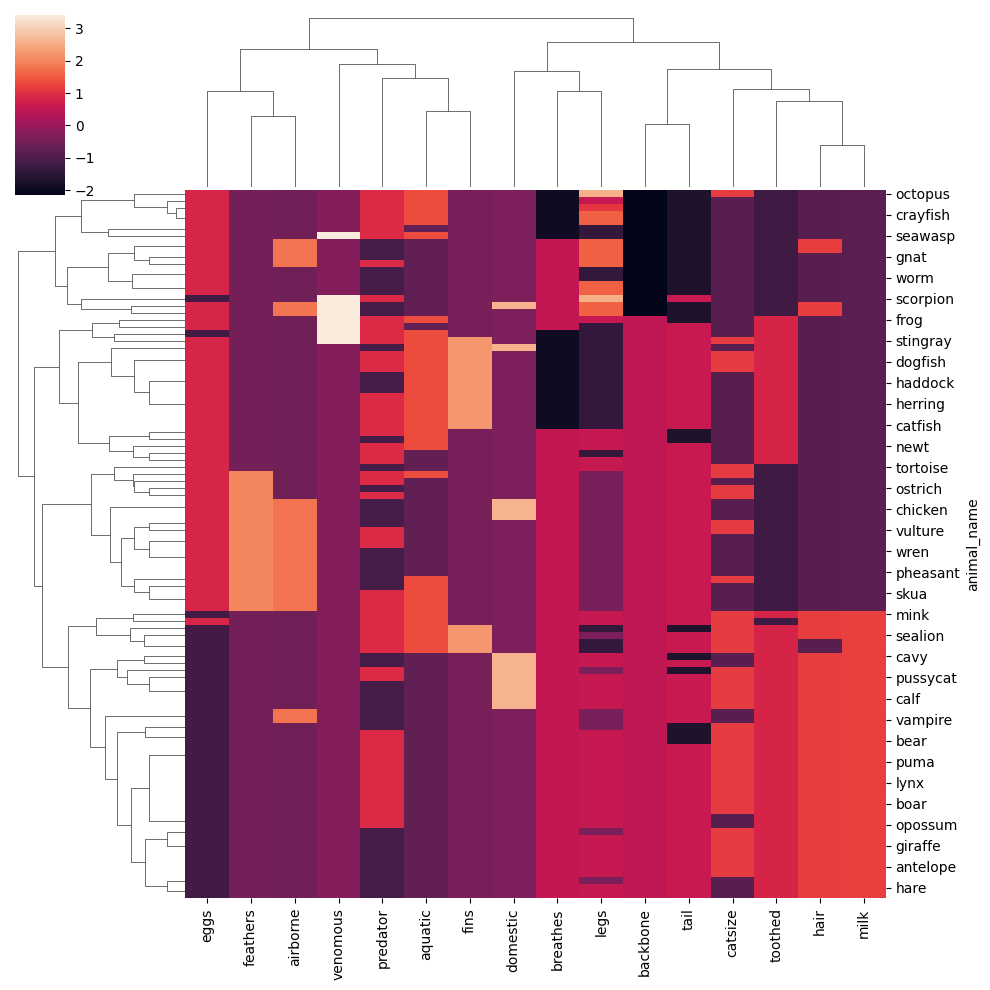

In [106]:
# Paso 4: Heatmap
import seaborn as sns

# Mapa sin los grupos definidos
sns.clustermap(df_scaled, method='complete', metric='euclidean')

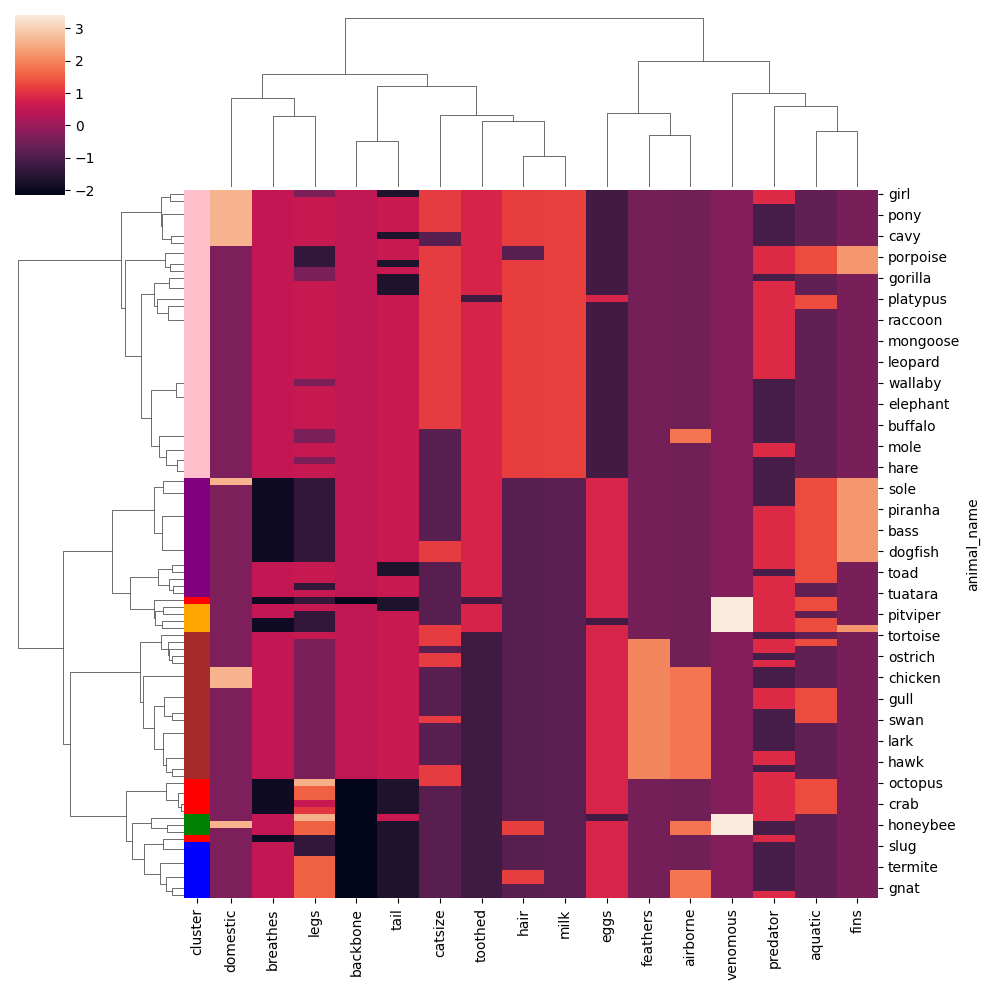

In [107]:
# Mapa con los clusters detectados:
import matplotlib.pyplot as plt

df_scaled['cluster'] = labels.astype(str)

sns.clustermap(df_scaled.drop('cluster', axis=1),
               row_colors=df_scaled['cluster'].map({
                   '1': 'red', '2': 'blue', '3': 'green', '4': 'orange', '5': 'purple',
                   '6': 'brown', '7': 'pink'
               }),
               method='ward', metric='euclidean', figsize=(10, 10))

plt.show()

In [108]:
# Evaluar clases originales con las obtenidas mediante clustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score

true_labels = df['class_type']  # Datos originales
predicted_labels = df_scaled['cluster']  # Datos clustering

ari = adjusted_rand_score(true_labels, predicted_labels)
nmi = normalized_mutual_info_score(true_labels, predicted_labels)
homogeneity = homogeneity_score(true_labels, predicted_labels)
completeness = completeness_score(true_labels, predicted_labels)
v_measure = v_measure_score(true_labels, predicted_labels)

print(f"Adjusted Rand Index (similitud entre campos): {ari:.4f}")
print(f"Normalized Mutual Information (cuanta info se comparten): {nmi:.4f}")
print(f"Homogeneity (que tan puros son los clusters / miembros de solo 1 clase): {homogeneity:.4f}")
print(f"Completeness (miembros de una clase asignados a 1 cluster): {completeness:.4f}")
print(f"V-measure (media entre homogeneidad y completitud): {v_measure:.4f}")

Adjusted Rand Index (similitud entre campos): 0.9110
Normalized Mutual Information (cuanta info se comparten): 0.8430
Homogeneity (que tan puros son los clusters / miembros de solo 1 clase): 0.8312
Completeness (miembros de una clase asignados a 1 cluster): 0.8551
V-measure (media entre homogeneidad y completitud): 0.8430


# Conclusiones
En conclusión, los clústers se lograron formar en la misma cantidad que el dataset original, siendo los grupos formados bastante similares a las etiquetas que venían predefinidas, en general se logró un buen desempeño del algoritmo bajo los parámetros definidos, aunque se podría mejorar, quizás mediante preprocesamiento, como tratamiento de datos extremos o érroneos.

## Pregunta 1
1. ¿Cuántos clusters se pueden identificar claramente en el dendrograma?

Depende de la cantidad de clústers que queramos obtener desde el dendograma, viendo que cada elemento podría ser un clúster por sí solo. No podría decir un número específico, pero el número 7 es el que representa una mejor agrupación de los datos.

## Pregunta 2
2. ¿Qué características parecen determinar la formación de los clusters?

La combinación de características es la que diferencia a un clúster de otro, pero hay uno que varía entre lectura, que sería el atributo "legs", el cual tiene distintos registros para animales diferentes, marcando una diferenciación más grande.

## Pregunta 3
3. ¿Los resultados del clustering tienen sentido biológico o zoológico?

Sí, ya que se agrupan distintas clases de animales según sus características biológicas, lo cual puede permitir tener ciertas zonas en un zoológico (por ejemplo) que se adapten mejor a las condiciones de cada grupo en específico.

## Pregunta 4
4. ¿Cómo afecta la normalización de los datos al clustering?

Afectan en gran medida ya que, al calcular distancias al momento de realizar el clústering (como la euclidiana por ejemplo), estas no reflejan la real distancia entre lecturas, viéndose afectado por la gran diferencia entre las escalas de las mediciones.

## Pregunta 5
5. ¿Qué método de linkage utilizaste y por qué?

Utilicé un método llamado "complete", el cual, para medir la distancia entre clústers, utiliza los puntos más lejanos de cada uno. Esta decisión se tomó ya que al evaluar distintos métodos, como ward o average, este resultó con un mejor puntaje general en base a ciertos paramétros, como silhouette. En este resultado se consideró además el número k óptimo para realizar el clústering.

## Pregunta 6
6. ¿Qué otras técnicas de clustering podrías aplicar a este dataset y por qué?

Dependiendo de la distribución de los datos, se podría utilizar k-means o dbscan, pero todo depende de la distribución que tengan estos datos y la tendencia a formar clústers que tenga el dataset.